> **Course notebook 6** | [Course home](../README.md) | [Previous: Complete preprocessing pipeline](05_llm_data_preprocessing_complete_pipeline.ipynb) | [Next: Simplified self-attention](simplified_self_attention_from_scratch.ipynb)

This lesson begins where the preprocessing course ended. It is conceptual preparation for implementing self-attention in the next notebook.

# Attention Foundations: From RNNs to Self-Attention

We previously transformed raw text into numerical input embeddings. Now the question changes:

> **How can one token use information from other tokens?**

This notebook explains why attention was introduced. It intentionally stops before Query/Key/Value matrices, scaled dot products, masking mathematics, and Transformer blocks.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle

np.random.seed(123)
plt.rcParams.update({
    "figure.figsize": (9, 3.8),
    "axes.grid": False,
    "font.size": 11,
})

COLORS = {
    "blue": "#3b82f6",
    "orange": "#f59e0b",
    "green": "#10b981",
    "red": "#ef4444",
    "purple": "#8b5cf6",
    "gray": "#64748b",
}

print("NumPy:", np.__version__)
print("Random seed: 123")

NumPy: 2.4.4
Random seed: 123


## 0. The big picture

```text
PREVIOUS NOTEBOOKS                   THIS NOTEBOOK

Raw text                             Input representations
  ↓                                        ↓
Tokenization                         How should sequence
  ↓                                  positions interact?
Token IDs                                   ↓
  ↓                                     ATTENTION
Token embeddings + positions
  ↓
Input representations
```

The wider learning path is:

```text
Stage 1: Data preparation → Attention mechanisms → LLM architecture
Stage 2: Training → Evaluation
Stage 3: Fine-tuning
```

> **Attention is fundamentally about deciding which pieces of information are relevant to the current computation.**

**Concept check:** What new ability must be added after creating input representations?

## 1. Motivating example: the cat sentence

> The cat that was sitting on the mat which was next to the dog jumped.

The nearest noun before *jumped* is *dog*, but the entity that jumped is *cat*. Understanding this sentence requires a **long-range dependency**: one position needs information from a considerably earlier or later position.

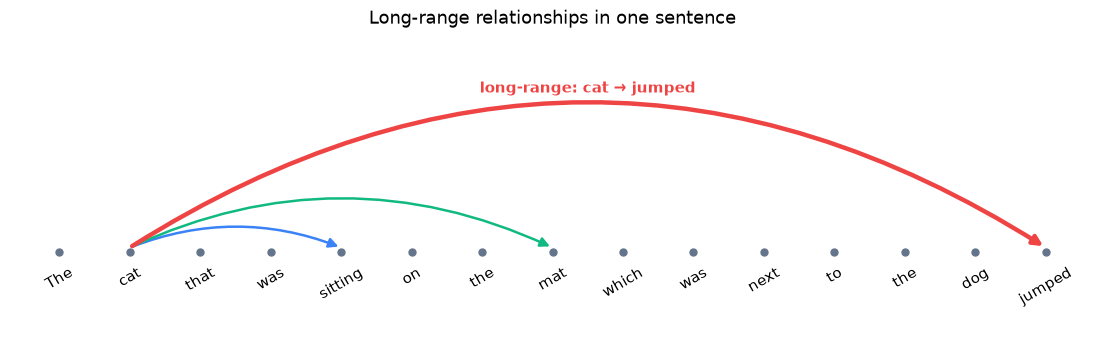

In [2]:
tokens = ["The", "cat", "that", "was", "sitting", "on", "the", "mat",
          "which", "was", "next", "to", "the", "dog", "jumped"]
x = np.arange(len(tokens))

fig, ax = plt.subplots(figsize=(14, 4))
ax.scatter(x, np.zeros_like(x), s=25, color=COLORS["gray"])
for i, token in enumerate(tokens):
    ax.text(i, -0.12, token, ha="center", va="top", rotation=30)

cat_index = tokens.index("cat")
links = [
    (tokens.index("sitting"), 0.8, COLORS["blue"], 1.8),
    (tokens.index("mat"), 1.15, COLORS["green"], 1.8),
    (tokens.index("jumped"), 1.65, COLORS["red"], 3.2),
]
for target, height, color, width in links:
    arrow = FancyArrowPatch(
        (cat_index, 0.04), (target, 0.04),
        connectionstyle=f"arc3,rad={-0.16 - 0.012 * (target-cat_index)}",
        arrowstyle="-|>", mutation_scale=14, lw=width, color=color
    )
    ax.add_patch(arrow)

ax.text((cat_index + tokens.index("jumped")) / 2, 1.45,
        "long-range: cat → jumped", ha="center", color=COLORS["red"],
        weight="bold")
ax.set(xlim=(-0.7, len(tokens) - 0.3), ylim=(-0.8, 2.0),
       title="Long-range relationships in one sentence")
ax.axis("off")
plt.show()

**What to notice:** the important relationship can cross many intervening tokens. Distance alone is not enough.

**Concept check:** Which two words form the most important long-range link for deciding who jumped?

## 2. Why word-by-word translation fails

Consider an artificial source sequence:

```text
Source labels:       S1  S2  S3  S4
Literal output:      can you me  help
Correct ordering:    can you help me
```

Translation cannot assume that source position 3 must become target position 3. Grammar, word order, meaning, and context can all change the alignment.

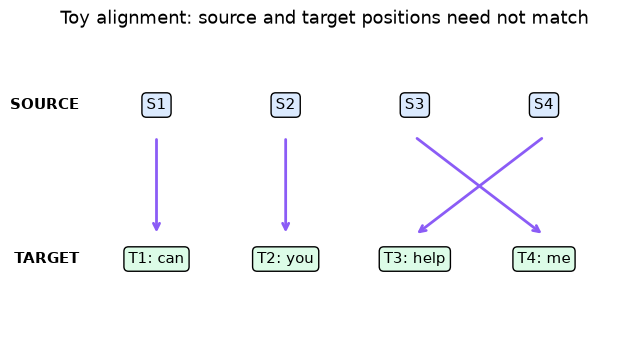

In [3]:
source = ["S1", "S2", "S3", "S4"]
target = ["T1: can", "T2: you", "T3: help", "T4: me"]
mapping = {0: 0, 1: 1, 2: 3, 3: 2}

fig, ax = plt.subplots(figsize=(8, 4))
for i, label in enumerate(source):
    ax.text(i, 1, label, ha="center", bbox=dict(boxstyle="round", fc="#dbeafe"))
for i, label in enumerate(target):
    ax.text(i, 0, label, ha="center", bbox=dict(boxstyle="round", fc="#dcfce7"))
for src_i, tgt_i in mapping.items():
    ax.annotate("", xy=(tgt_i, 0.18), xytext=(src_i, 0.82),
                arrowprops=dict(arrowstyle="->", color=COLORS["purple"], lw=2))
ax.text(-0.6, 1, "SOURCE", ha="right", weight="bold")
ax.text(-0.6, 0, "TARGET", ha="right", weight="bold")
ax.set(xlim=(-1.1, 3.7), ylim=(-0.5, 1.5),
       title="Toy alignment: source and target positions need not match")
ax.axis("off")
plt.show()

**What to notice:** two alignment arrows cross. Sequence modeling requires context, not independent token replacement.

**Concept check:** Why does `S3 → T4` contradict position-by-position translation?

## 3. Why sequence models need memory

```text
"Harry entered Station 9¾." → several sentences → "He returned to the station."

x1 → x2 → x3 → x4 → x5
└───────────────────────↑
      x1 matters at x5
```

**Memory** is a representation carrying useful information from previous sequence positions. Without it, later words cannot benefit from earlier context.

**What to notice:** memory is not a verbatim copy of every earlier token; it is a useful carried representation.

**Concept check:** What earlier detail helps interpret “the station” later?

## 4. Vanilla RNN intuition

A recurrent neural network updates a hidden state one position at a time:

\[
h_t = f(x_t, h_{t-1})
\]

`x_t` is the current input and `h_t` is the new **hidden state**. The state mixes the current input with information carried from the previous step.

```text
x1 → [RNN] → h1 → [RNN] → h2 → [RNN] → h3 → [RNN] → h4
               ↑x2          ↑x3          ↑x4
```

t=1: x_t= 0.8, h_t=  0.617
t=2: x_t=-0.2, h_t=  0.188
t=3: x_t= 0.5, h_t=  0.510
t=4: x_t= 1.0, h_t=  0.835
t=5: x_t=-0.4, h_t=  0.140


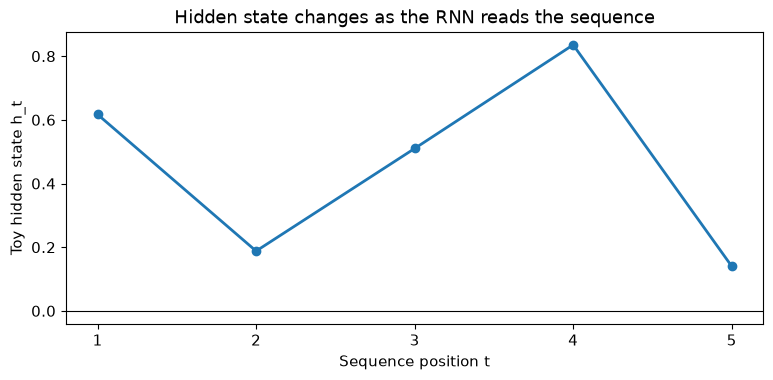

In [4]:
# Scalar toy recurrence: h_t = tanh(Wx*x_t + Wh*h_{t-1})
sequence = np.array([0.8, -0.2, 0.5, 1.0, -0.4])
W_x, W_h = 0.9, 0.6
hidden = [0.0]

for x_t in sequence:
    hidden.append(np.tanh(W_x * x_t + W_h * hidden[-1]))

hidden = np.array(hidden[1:])
for t, (x_t, h_t) in enumerate(zip(sequence, hidden), start=1):
    print(f"t={t}: x_t={x_t:>4.1f}, h_t={h_t:>7.3f}")

plt.plot(range(1, len(hidden) + 1), hidden, marker="o", lw=2)
plt.axhline(0, color="black", lw=0.8)
plt.xticks(range(1, len(hidden) + 1))
plt.xlabel("Sequence position t")
plt.ylabel("Toy hidden state h_t")
plt.title("Hidden state changes as the RNN reads the sequence")
plt.show()

**Illustrative toy recurrence — not a realistic language model.**

**What to notice:** each `h_t` depends on both the new input and the previous state.

**Concept check:** if `h_2` changes, can that influence `h_4`?

## 5. Why it is called recurrent

```text
previous hidden state
         ↓
current recurrent computation
         ↓
  new hidden state
         ↓
 next recurrent computation
```

The same type of computation repeats across sequence positions, and its output returns as input to the next step.

**Question:** What makes an RNN different from an ordinary feed-forward model when processing a sequence?

*Save your answer; the answer section appears later.*

## 6. Encoder–decoder architecture

Classic sequence-to-sequence models separate reading from generation:

```text
SOURCE SENTENCE
       ↓
    ENCODER       processes the source
       ↓
 CONTEXT VECTOR   summarizes source information
       ↓
    DECODER       generates the target
       ↓
TARGET SENTENCE
```

**What to notice:** the encoder and decoder have different roles, connected through a numerical context.

**Concept check:** Which component reads the source, and which produces the target?

## 7. Final hidden state as context

In a simplified classic recurrent encoder–decoder, the final encoder state summarizes the entire source:

```text
x1 → h1 → h2 → h3 → h4
                      ↓
            final hidden state
                      ↓
                   decoder
```

The decoder receives `h4`; it does **not** directly retrieve `h1`, `h2`, or `h3` in this fixed-context design.

**What to notice:** every earlier detail must survive through the chain and be represented in `h4`.

**Concept check:** Where must information from `x1` be stored by the time encoding ends?

## 8. The fixed-context bottleneck

Short and long inputs are both compressed into the same-sized context vector. It is like requiring everything to fit into one suitcase.

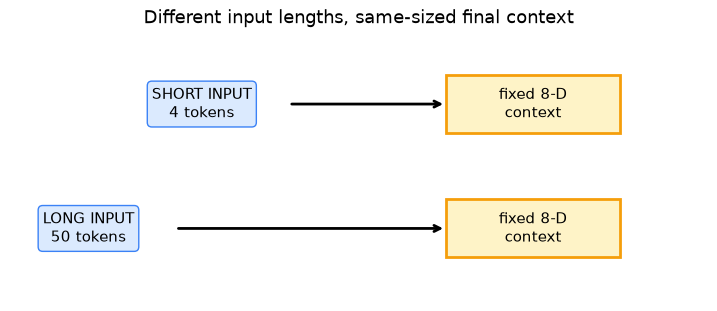

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.5))
examples = [("SHORT INPUT\n4 tokens", 2.2), ("LONG INPUT\n50 tokens", 0.9)]

for y, (label, start_x) in zip([1.9, 0.7], examples):
    ax.text(start_x, y, label, ha="center", va="center",
            bbox=dict(boxstyle="round", fc="#dbeafe", ec=COLORS["blue"]))
    ax.annotate("", xy=(5.0, y), xytext=(start_x + 1.0, y),
                arrowprops=dict(arrowstyle="->", lw=2))
    ax.add_patch(Rectangle((5.0, y - 0.28), 2.0, 0.56,
                           fc="#fef3c7", ec=COLORS["orange"], lw=2))
    ax.text(6.0, y, "fixed 8-D\ncontext", ha="center", va="center")

ax.set(xlim=(0, 8), ylim=(0, 2.6),
       title="Different input lengths, same-sized final context")
ax.axis("off")
plt.show()

**What to notice:** more information must fit into no more space. This can cause **loss of context**, especially for long or complex sequences.

**Concept check:** Does the context vector grow when the source grows from 4 to 50 tokens here?

## 9. What if the hidden state is huge?

A larger hidden state increases representational **capacity**, but it does not remove the architectural requirement to use one final summary.

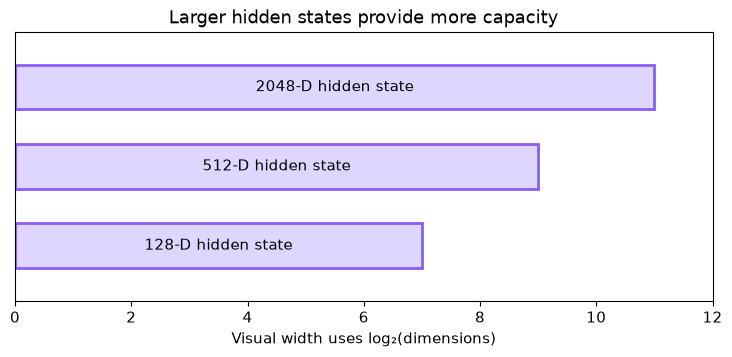

10-token input   → 2048-D summary
100-token input  → 2048-D summary
1000-token input → 2048-D summary


In [6]:
dimensions = [128, 512, 2048]
widths = np.log2(dimensions)

fig, ax = plt.subplots(figsize=(9, 3.5))
for y, (dim, width) in enumerate(zip(dimensions, widths)):
    ax.add_patch(Rectangle((0, y - 0.28), width, 0.56,
                           fc="#ddd6fe", ec=COLORS["purple"], lw=2))
    ax.text(width / 2, y, f"{dim}-D hidden state", ha="center", va="center")
ax.set(xlim=(0, max(widths) + 1), ylim=(-0.7, 2.7),
       title="Larger hidden states provide more capacity")
ax.set_yticks([])
ax.set_xlabel("Visual width uses log₂(dimensions)")
plt.show()

print("10-token input   → 2048-D summary")
print("100-token input  → 2048-D summary")
print("1000-token input → 2048-D summary")

> **Bigger suitcase ≠ no suitcase bottleneck.**

- **Capacity problem:** is the representation large enough?
- **Architectural access problem:** can the decoder directly retrieve individual source representations?

**Concept check:** Which problem remains even after increasing the hidden state to 2048 dimensions?

## 10. Vanishing-gradient intuition

Training sends information backward through the recurrent chain:

```text
loss → h100 → h99 → … → h2 → h1
```

Repeated multiplication by values below 1 can make a learning signal very small.

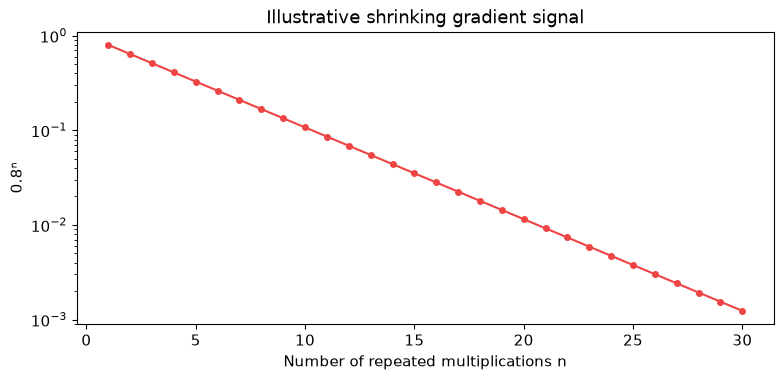

After 5 steps:  0.3277
After 30 steps: 0.001238


In [7]:
steps = np.arange(1, 31)
gradient_scale = 0.8 ** steps

plt.plot(steps, gradient_scale, marker="o", markersize=4, color=COLORS["red"])
plt.xlabel("Number of repeated multiplications n")
plt.ylabel("0.8ⁿ")
plt.title("Illustrative shrinking gradient signal")
plt.yscale("log")
plt.show()

print(f"After 5 steps:  {0.8**5:.4f}")
print(f"After 30 steps: {0.8**30:.6f}")

**Illustrative intuition — real RNN gradients involve matrices and nonlinearities.**

**What to notice:** the signal shrinks rapidly across many steps, making distant dependencies harder to learn.

**Concept check:** would repeated multiplication by `0.8` strengthen or weaken the signal?

## 11. Where LSTM enters

**Long Short-Term Memory (LSTM)** networks were developed to preserve and learn long-term information more effectively than vanilla RNNs.

```text
cell state ─────────────────────────────────────→
            ↑          ↑          ↑          ↑
           gates      gates      gates      gates
```

The **cell state** provides a controlled memory path. A forget gate controls what is retained, an input gate controls what is added, and an output gate controls what is exposed.

**What to notice:** LSTM is still recurrent, but it manages memory with learned gates.

**Concept check:** Does LSTM remove the step-by-step recurrence?

## 12. LSTM does not make attention unnecessary

These mechanisms address different questions:

| Problem | Mechanism that helps |
|---|---|
| Can useful information survive many recurrent steps? | LSTM |
| Can the decoder directly access individual source representations? | Attention |

```text
WITHOUT ATTENTION                   WITH ATTENTION

x1 → h1                             h1 ─┐
x2 → h2                             h2 ─┤
...                                 ... ├──→ decoder
x100 → h100 → decoder               h100┘
```

Attention historically worked **with** RNN/LSTM encoder–decoder models.

**Concept check:** Which mechanism gives the decoder dynamic access to `h1 … h100`?

## 13. RNN vs LSTM vs attention

| Model | Memory and information flow | Main limitation or change |
|---|---|---|
| Vanilla RNN | Recurrent hidden state | Long-term training can be difficult |
| LSTM | Gated recurrent memory | Still sequential and recurrent |
| RNN/LSTM + attention | Decoder dynamically accesses encoder states | Less dependence on one final context |
| Transformer | Attention is the main interaction mechanism | Recurrence is not required |

**What to notice:** attention did not redefine memory gates; it changed access to sequence information.

**Concept check:** Which row first removes the need for a recurrent hidden-state chain?

## 14. Introducing Bahdanau attention

In 2014, *Neural Machine Translation by Jointly Learning to Align and Translate* introduced a widely influential attention approach for recurrent translation models.

```text
BEFORE                              WITH ATTENTION

h1 → h2 → h3 → h4                   h1 ─┐
                 ↓                   h2 ─┤
              decoder               h3 ─┤──→ decoder
                                    h4 ─┘
```

Instead of depending only on `h_n`, the decoder retains access to `h1, h2, …, h_n`.

**Concept check:** What information becomes directly available to the decoder?

## 15. Attention weights

At one decoder step, a weight describes how strongly each encoder representation contributes to the current context.

> **Illustrative values — not learned from a real model. These weights are manually chosen for visualization.**

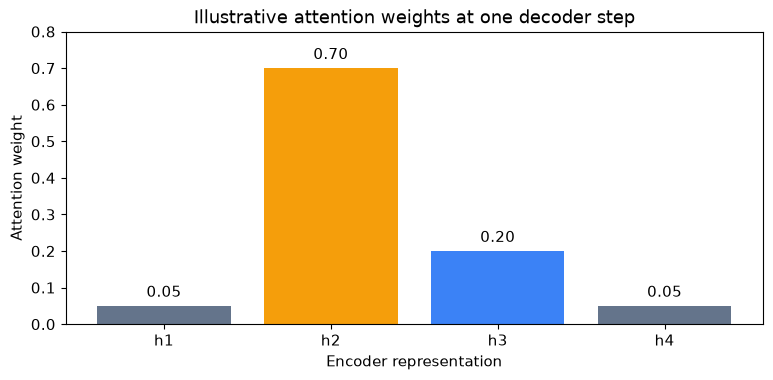

Weight sum: 1.0


In [8]:
encoder_labels = ["h1", "h2", "h3", "h4"]
attention_weights = np.array([0.05, 0.70, 0.20, 0.05])

assert np.isclose(attention_weights.sum(), 1.0)
plt.bar(encoder_labels, attention_weights,
        color=[COLORS["gray"], COLORS["orange"], COLORS["blue"], COLORS["gray"]])
plt.ylim(0, 0.8)
plt.xlabel("Encoder representation")
plt.ylabel("Attention weight")
plt.title("Illustrative attention weights at one decoder step")
for i, value in enumerate(attention_weights):
    plt.text(i, value + 0.025, f"{value:.2f}", ha="center")
plt.show()

print("Weight sum:", attention_weights.sum())

**What to notice:** `h2` contributes most at this decoder step, and the simplified weights sum to 1.

**Concept check:** Which encoder state has the strongest contribution?

## 16. Weighted context vector

A dynamic context can be a weighted sum of encoder states:

\[
context = \alpha_1h_1 + \alpha_2h_2 + \alpha_3h_3 + \alpha_4h_4
\]

The following states and weights are deliberately small.

0.05 × h1 [1. 0.] = [0.05 0.  ]
0.70 × h2 [2. 1.] = [1.4 0.7]
0.20 × h3 [0. 2.] = [0.  0.4]
0.05 × h4 [1. 3.] = [0.05 0.15]
context = [1.5  1.25]


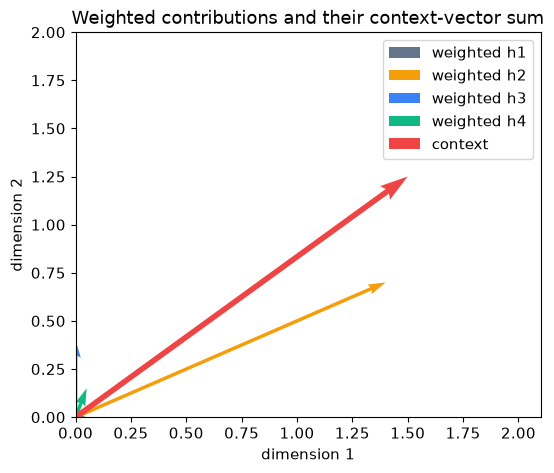

In [9]:
encoder_states = np.array([
    [1.0, 0.0],
    [2.0, 1.0],
    [0.0, 2.0],
    [1.0, 3.0],
])
alpha = np.array([0.05, 0.70, 0.20, 0.05])
contributions = alpha[:, None] * encoder_states
context = contributions.sum(axis=0)

for label, weight, state, contribution in zip(
    encoder_labels, alpha, encoder_states, contributions
):
    print(f"{weight:.2f} × {label} {state} = {contribution}")
print("context =", context)

fig, ax = plt.subplots(figsize=(6, 5))
origin = np.zeros(2)
for label, vector, color in zip(
    encoder_labels, contributions,
    [COLORS["gray"], COLORS["orange"], COLORS["blue"], COLORS["green"]]
):
    ax.quiver(*origin, *vector, angles="xy", scale_units="xy", scale=1,
              color=color, label=f"weighted {label}")
ax.quiver(*origin, *context, angles="xy", scale_units="xy", scale=1,
          color=COLORS["red"], width=0.012, label="context")
ax.set(xlim=(0, 2.1), ylim=(0, 2.0), xlabel="dimension 1", ylabel="dimension 2",
       title="Weighted contributions and their context-vector sum")
ax.legend()
plt.show()

**Illustrative values — not learned from a real model.**

**What to notice:** the context is dynamically built from several encoder states; it is not simply the final state.

**Concept check:** Why does `h2` have the largest effect here?

## 17. Dynamic focus

The decoder can use a different attention pattern at each output step. This is **dynamic focus**: what matters depends on what the model is currently producing.

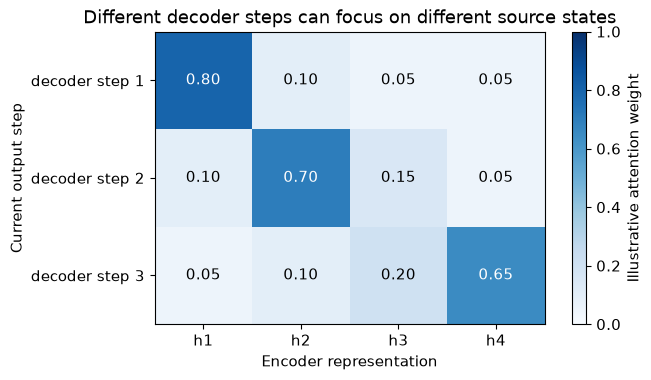

In [10]:
dynamic_weights = np.array([
    [0.80, 0.10, 0.05, 0.05],
    [0.10, 0.70, 0.15, 0.05],
    [0.05, 0.10, 0.20, 0.65],
])
assert np.allclose(dynamic_weights.sum(axis=1), 1.0)

fig, ax = plt.subplots(figsize=(7, 3.8))
image = ax.imshow(dynamic_weights, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(4), encoder_labels)
ax.set_yticks(range(3), ["decoder step 1", "decoder step 2", "decoder step 3"])
ax.set_xlabel("Encoder representation")
ax.set_ylabel("Current output step")
ax.set_title("Different decoder steps can focus on different source states")
for row in range(3):
    for col in range(4):
        ax.text(col, row, f"{dynamic_weights[row, col]:.2f}",
                ha="center", va="center",
                color="white" if dynamic_weights[row, col] > 0.5 else "black")
fig.colorbar(image, ax=ax, label="Illustrative attention weight")
plt.show()

**Illustrative values — not learned from a real model.**

**What to notice:** the brightest cell moves from `h1` to `h2` to `h4`.

**Concept check:** Must every decoder step use the same context vector?

## 18. Long-range dependency with attention

Return to the cat sentence. For a computation related to *jumped*, a distant representation for *cat* can receive high relevance even though *dog* is closer.

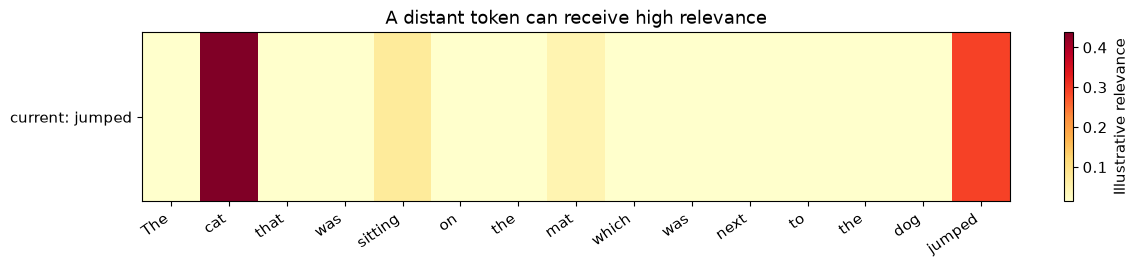

In [11]:
cat_relevance = np.full(len(tokens), 0.015)
cat_relevance[cat_index] = 0.48
cat_relevance[tokens.index("jumped")] = 0.32
cat_relevance[tokens.index("sitting")] = 0.08
cat_relevance[tokens.index("mat")] = 0.05
cat_relevance = cat_relevance / cat_relevance.sum()

fig, ax = plt.subplots(figsize=(14, 2.2))
image = ax.imshow(cat_relevance[None, :], cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(tokens)), tokens, rotation=35, ha="right")
ax.set_yticks([0], ["current: jumped"])
ax.set_title("A distant token can receive high relevance")
fig.colorbar(image, ax=ax, label="Illustrative relevance")
plt.show()

**Illustrative values — not learned from a real model.**

**What to notice:** relevance is not determined by physical closeness.

**Concept check:** Which distant token is highlighted most strongly?

## 19. Precision note: what receives attention?

> In RNN-based attention, the decoder generally attends to **encoder representations / hidden states** associated with source positions.

```text
source token x3 → encoder → hidden representation h3 → attention uses h3
```

It is more precise to say “attention over `h1, h2, …, h_n`” than “attention over raw token IDs.”

**Concept check:** Does the decoder weight the integer token ID directly in this design?

## 20. Learned alignment

Attention does not assume position 1 maps to position 1. The matrix below represents a conceptual learned alignment:

```text
A → W,  B → Y,  C → Z,  D → X
```

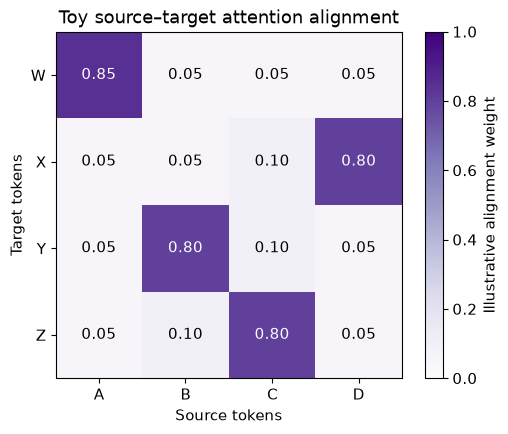

In [12]:
source_labels = ["A", "B", "C", "D"]
target_labels = ["W", "X", "Y", "Z"]
alignment = np.array([
    [0.85, 0.05, 0.05, 0.05],  # W focuses on A
    [0.05, 0.05, 0.10, 0.80],  # X focuses on D
    [0.05, 0.80, 0.10, 0.05],  # Y focuses on B
    [0.05, 0.10, 0.80, 0.05],  # Z focuses on C
])

fig, ax = plt.subplots(figsize=(6, 4.5))
image = ax.imshow(alignment, cmap="Purples", vmin=0, vmax=1)
ax.set_xticks(range(4), source_labels)
ax.set_yticks(range(4), target_labels)
ax.set_xlabel("Source tokens")
ax.set_ylabel("Target tokens")
ax.set_title("Toy source–target attention alignment")
for row in range(4):
    for col in range(4):
        ax.text(col, row, f"{alignment[row, col]:.2f}",
                ha="center", va="center",
                color="white" if alignment[row, col] > 0.5 else "black")
fig.colorbar(image, ax=ax, label="Illustrative alignment weight")
plt.show()

**Illustrative values — not learned from a real model.**

**What to notice:** bright cells do not form a simple diagonal; target order differs from source order.

**Concept check:** Which source position contributes most to target `X`?

## 21. Why alignment matters in translation

**Toy reordering example — not a real language translation:**

```text
Source:     European  economic  area
Target:     European  area      economic

            European ─────────→ European
            economic ──────────→ economic
            area ─────────→ area
```

The crossing relationships show that useful alignment is independent of identical positions.

**Concept check:** Which two source items exchange order in the toy target?

## 22. Attention weights are learned

Humans do not assign real attention weights:

```text
training data
     ↓
model prediction
     ↓
    loss
     ↓
backpropagation
     ↓
parameters change
     ↓
useful attention patterns may emerge
```

The numerical weights used earlier were manually chosen **only for visualization**.

**Concept check:** What training signal ultimately drives parameter changes?

## 23. Timeline of sequence modeling

The timeline below emphasizes the architectural idea introduced at each milestone.

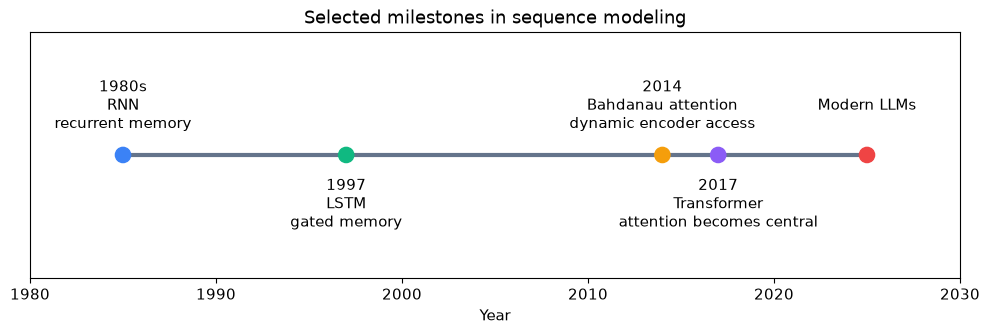

In [13]:
years = [1985, 1997, 2014, 2017, 2025]
labels = [
    "1980s\nRNN\nrecurrent memory",
    "1997\nLSTM\ngated memory",
    "2014\nBahdanau attention\ndynamic encoder access",
    "2017\nTransformer\nattention becomes central",
    "Modern LLMs",
]

fig, ax = plt.subplots(figsize=(12, 3.2))
ax.plot(years, np.zeros(len(years)), color=COLORS["gray"], lw=3)
ax.scatter(years, np.zeros(len(years)), s=120,
           c=[COLORS["blue"], COLORS["green"], COLORS["orange"],
              COLORS["purple"], COLORS["red"]], zorder=3)
for i, (year, label) in enumerate(zip(years, labels)):
    y = 0.28 if i % 2 == 0 else -0.28
    ax.text(year, y, label, ha="center", va="center")
ax.set(xlim=(1980, 2030), ylim=(-0.7, 0.7),
       title="Selected milestones in sequence modeling")
ax.set_xlabel("Year")
ax.set_yticks([])
plt.show()

**What to notice:** attention first complemented recurrent models; the Transformer later made attention central without requiring recurrence.

**Concept check:** Which milestone changed attention from an addition to the primary interaction mechanism?

## 24. The Transformer's big architectural change

```text
RECURRENT MODEL                    TRANSFORMER

token 1                            token-position representations
  ↓                                  ↕    ↕    ↕    ↕
token 2                              attention interactions
  ↓
token 3
  ↓
token 4
```

A recurrent model passes context through a hidden-state chain. A Transformer allows attention interactions without that chain.

Initial Transformer representations contain **token information + positional information**. Attention then operates between these combined token-position representations.

**Concept check:** Is a recurrent hidden-state chain required by the Transformer?

## 25. Positional information vs attention

| Component | Question it helps answer |
|---|---|
| Token embedding | “What token is this?” |
| Positional information | “Where is this token?” |
| Self-attention | “Which other token representations are relevant?” |

```text
The → T + P0
cat → C + P1      self-attention operates among T+P0, C+P1, S+P2
sat → S + P2
```

> **Transformer attention does not merely compare positional embeddings.** Position is included so order is available while full token-position representations interact.

**Concept check:** What would be missing if position information were removed?

## 26. Traditional encoder–decoder attention

```text
SOURCE ENCODER                         TARGET DECODER
S1 representation ─┐
S2 representation ─┼──── attention ───→ T2
S3 representation ─┤
S4 representation ─┘
```

At decoder step `T2`, traditional attention can combine information from all source encoder representations. It connects different parts of an encoder–decoder system.

**Concept check:** Are the source and target roles the same sequence here?

## 27. Self-attention

**Self** means the related representations belong to the **same sequence**.

> **self-attention ≠ a token looking only at itself**  
> **self-attention = same-sequence attention**

We will visualize conceptual links without calculating them yet.

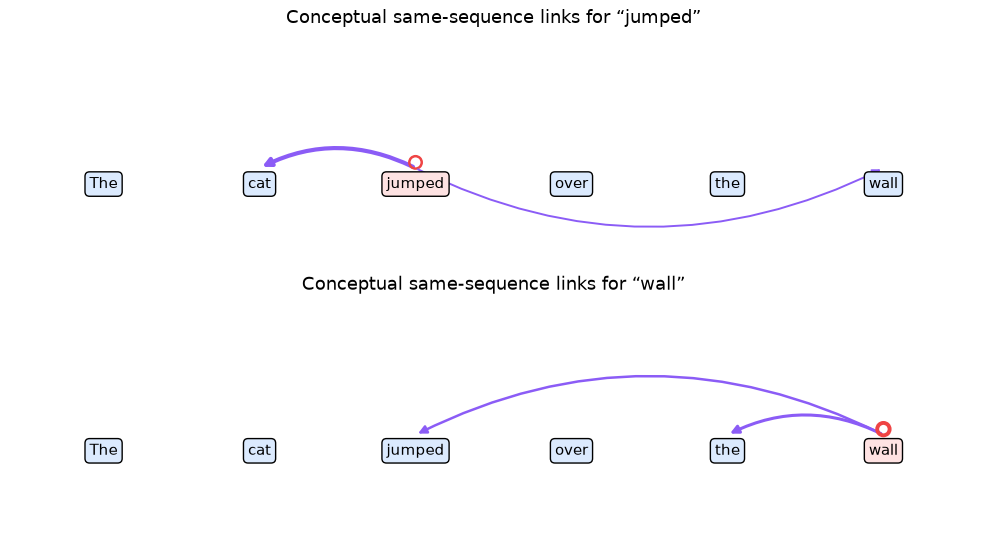

In [14]:
self_tokens = ["The", "cat", "jumped", "over", "the", "wall"]
positions = np.arange(len(self_tokens))

fig, axes = plt.subplots(2, 1, figsize=(10, 5.5))
patterns = {
    "jumped": [("cat", 3.0), ("jumped", 1.8), ("wall", 1.4)],
    "wall": [("jumped", 1.8), ("the", 2.2), ("wall", 2.8)],
}

for ax, (focus, links) in zip(axes, patterns.items()):
    for i, token in enumerate(self_tokens):
        face = "#fee2e2" if token == focus else "#dbeafe"
        ax.text(i, 0, token, ha="center",
                bbox=dict(boxstyle="round", fc=face))
    focus_i = self_tokens.index(focus)
    for target, width in links:
        target_i = self_tokens.index(target)
        if target_i == focus_i:
            ax.scatter([focus_i], [0.18], s=80, facecolors="none",
                       edgecolors=COLORS["red"], lw=width)
        else:
            arrow = FancyArrowPatch(
                (focus_i, 0.14), (target_i, 0.14),
                connectionstyle="arc3,rad=0.25", arrowstyle="-|>",
                mutation_scale=12, lw=width, color=COLORS["purple"]
            )
            ax.add_patch(arrow)
    ax.set(xlim=(-0.6, len(self_tokens) - 0.4), ylim=(-0.5, 1.1))
    ax.set_title(f"Conceptual same-sequence links for “{focus}”")
    ax.axis("off")
plt.tight_layout()
plt.show()

**Illustrative links — not learned from a real model.**

**What to notice:** *jumped* and *wall* can use different same-sequence relationships.

**Concept check:** Does “self” restrict a position to itself?

## 28. Static vs contextual representation

```text
"I deposited money at the bank."
"We sat near the river bank."

same initial bank token embedding
               ↓
different surrounding context
               ↓
         self-attention
               ↓
different contextual representations
```

If tokenization produces the same *bank* token, it begins with the same token embedding. Interactions with *money/deposited* versus *river/sat* allow deeper representations to differ.

**What to notice:** an embedding lookup is initially static; contextual processing changes the representation used later.

**Concept check:** Which surrounding word most clearly separates the two meanings?

## 29. Self-attention vs RNN information flow

In an RNN, early information travels through intermediate states. Self-attention provides more direct conceptual interaction between positions.

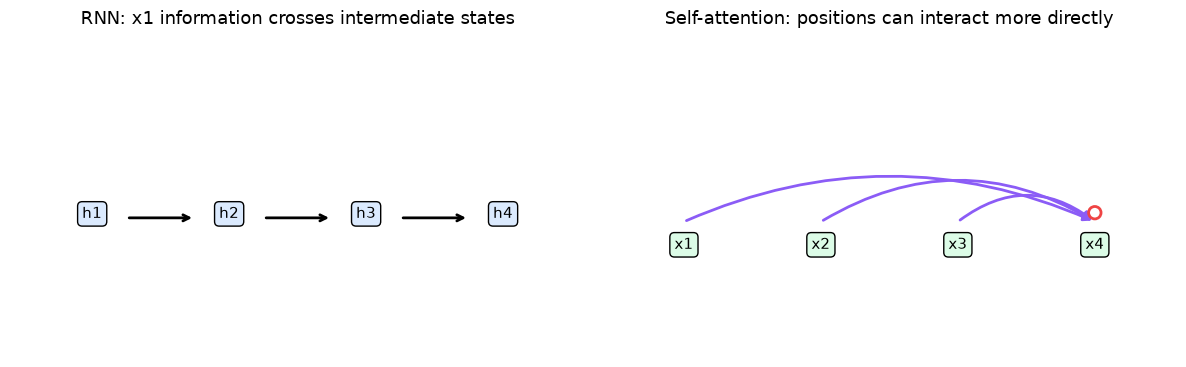

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

# RNN chain
for i in range(4):
    axes[0].text(i, 0, f"h{i+1}", ha="center",
                 bbox=dict(boxstyle="round", fc="#dbeafe"))
    if i < 3:
        axes[0].annotate("", xy=(i + 0.75, 0), xytext=(i + 0.25, 0),
                         arrowprops=dict(arrowstyle="->", lw=2))
axes[0].set_title("RNN: x1 information crosses intermediate states")
axes[0].set(xlim=(-0.6, 3.6), ylim=(-0.6, 0.8))
axes[0].axis("off")

# Direct conceptual links to x4
for i in range(4):
    axes[1].text(i, 0, f"x{i+1}", ha="center",
                 bbox=dict(boxstyle="round", fc="#dcfce7"))
for i in range(3):
    arrow = FancyArrowPatch(
        (i, 0.15), (3, 0.15),
        connectionstyle=f"arc3,rad={-0.22 - i*0.08}",
        arrowstyle="-|>", mutation_scale=12, lw=2, color=COLORS["purple"]
    )
    axes[1].add_patch(arrow)
axes[1].scatter([3], [0.2], s=80, facecolors="none",
                edgecolors=COLORS["red"], lw=2)
axes[1].set_title("Self-attention: positions can interact more directly")
axes[1].set(xlim=(-0.6, 3.6), ylim=(-0.6, 1.2))
axes[1].axis("off")

plt.tight_layout()
plt.show()

**What to notice:** the conceptual path from `x1` to `x4` is shorter in the self-attention picture.

**Concept check:** Through how many intermediate recurrent states must `x1` pass to influence `h4`?

## 30. Traditional attention vs self-attention

| Traditional encoder–decoder attention | Self-attention |
|---|---|
| Decoder state relates to encoder representations | Positions relate within one sequence |
| Often illustrated with translation | Core Transformer interaction |
| Distinct source and target roles | Same-sequence representations |

**Concept check:** Which type describes interactions among positions in one GPT input sequence?

## 31. Preview: causal attention

GPT predicts the next token, so a position must not use future tokens. A **causal** visibility rule allows each position to see itself and earlier positions only.

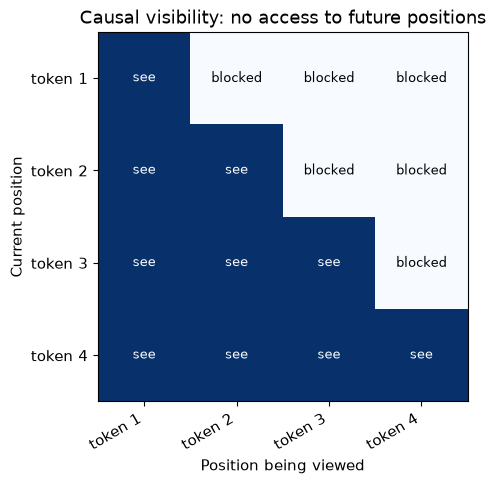

token 1 sees: 1
token 2 sees: 1 2
token 3 sees: 1 2 3
token 4 sees: 1 2 3 4


In [16]:
causal_visibility = np.tril(np.ones((4, 4), dtype=int))

fig, ax = plt.subplots(figsize=(5.8, 4.8))
image = ax.imshow(causal_visibility, cmap="Blues", vmin=0, vmax=1)
labels = ["token 1", "token 2", "token 3", "token 4"]
ax.set_xticks(range(4), labels, rotation=30, ha="right")
ax.set_yticks(range(4), labels)
ax.set_xlabel("Position being viewed")
ax.set_ylabel("Current position")
ax.set_title("Causal visibility: no access to future positions")
for row in range(4):
    for col in range(4):
        ax.text(col, row, "see" if causal_visibility[row, col] else "blocked",
                ha="center", va="center",
                color="white" if causal_visibility[row, col] else "black",
                fontsize=9)
plt.show()

for row, label in enumerate(labels):
    visible = [str(i + 1) for i in range(4) if causal_visibility[row, i]]
    print(f"{label} sees: {' '.join(visible)}")

**What to notice:** the allowed region is triangular; cells above the diagonal are blocked.

**We will implement this properly in a later notebook.**

**Concept check:** Can token 2 use token 4 while learning next-token prediction?

## 32. Preview: multi-head attention

```text
                 ┌→ attention head 1 ─┐
same sequence ───┼→ attention head 2 ─┼→ combined representation
                 ├→ attention head 3 ─┤
                 └→ attention head 4 ─┘
```

Multiple heads provide several learned attention projections or representation subspaces in parallel. Heads are **not** manually assigned rigid jobs such as “nouns” or “verbs.”

**What to notice:** the model learns how the parallel heads become useful.

**Concept check:** Are semantic duties predefined for each head?

## 33. Attention learning roadmap

```text
YOU ARE HERE
Conceptual foundations
         ↓
NEXT: Simplified self-attention
         ↓
Self-attention with trainable parameters
         ↓
Causal attention
         ↓
Multi-head attention
         ↓
Transformer block
```

The next notebook begins the mathematics and Python implementation. No Query/Key/Value calculations are introduced here.

## 34. Complete concept map

```text
Independent token processing fails
                ↓
Sequences require context
                ↓
RNN → hidden-state memory
                ↓
Long-term training difficulties
                ↓
LSTM → better controlled recurrent memory
                ↓
Classic encoder–decoder fixed-context bottleneck
                ↓
Bahdanau attention
                ↓
Dynamic access to encoder states
                ↓
Attention weights → dynamic context → learned alignment
                ↓
Transformer removes recurrence as a core requirement
                ↓
Self-attention → same-sequence interaction
                ↓
Causal self-attention → multi-head attention
                ↓
GPT-style Transformer
```

**Concept check:** Which step changes one fixed context into dynamic access?

## 35. Common confusions

**Do RNNs have no memory?**  
No. Hidden states are recurrent memory.

**Can a larger hidden state help?**  
Yes, it increases capacity, but one final summary remains one final summary.

**Didn't LSTM solve long-term dependencies?**  
It improved recurrent memory and gradient flow. Attention adds direct dynamic access to relevant representations.

**Did attention immediately replace LSTM?**  
No. Attention was first widely used with recurrent encoder–decoder models.

**Does Transformer attention use only positional embeddings?**  
No. It operates on representations containing token and positional information.

**Does self-attention mean a token attends only to itself?**  
No. “Self” means positions from the same sequence.

**Are attention weights manually assigned?**  
No. Real weights emerge from learned parameters; ours were illustrative.

**Must attention favor the closest word?**  
No. Distant positions can receive high relevance.

## 36. Mini theory quiz

Answer without running new code. Do not open the answer section yet.

1. Why can word-by-word translation fail?
2. What does sequence context provide?
3. What does memory mean in an RNN?
4. What is a hidden state?
5. Why is an RNN called recurrent?
6. What does an encoder do?
7. What does a decoder do?
8. What is a context vector?
9. How was the final hidden state used in a classic fixed-context model?
10. What is the fixed-context bottleneck?
11. How does a larger hidden state help?
12. Why does a larger state not remove the bottleneck?
13. What is a long-range dependency?
14. What is the intuition behind a vanishing gradient?
15. Why was LSTM introduced?
16. What role does the LSTM cell state play?
17. Why does LSTM not remove the usefulness of attention?
18. What did Bahdanau attention change?
19. In recurrent attention, what does the decoder attend over?
20. What does a larger attention weight mean?
21. How is a weighted context vector formed conceptually?
22. What is dynamic focus?
23. What is learned alignment?
24. Why is 2014 important in this timeline?
25. Why is 2017 important?
26. How does Transformer information flow differ from recurrent flow?
27. What does positional information contribute?
28. What is traditional encoder–decoder attention?
29. What is self-attention?
30. What does “self” mean?
31. How can the two meanings of *bank* become contextually different?
32. Why is causal attention needed for GPT?
33. What is the basic purpose of multiple attention heads?

## 37. Visual identification quiz

Identify each pattern:

- **A.** Vanilla RNN
- **B.** Encoder–decoder with fixed context
- **C.** Attention-enhanced encoder–decoder
- **D.** Self-attention
- **E.** Causal attention

The diagrams are intentionally schematic. Record your answers before opening the solutions.

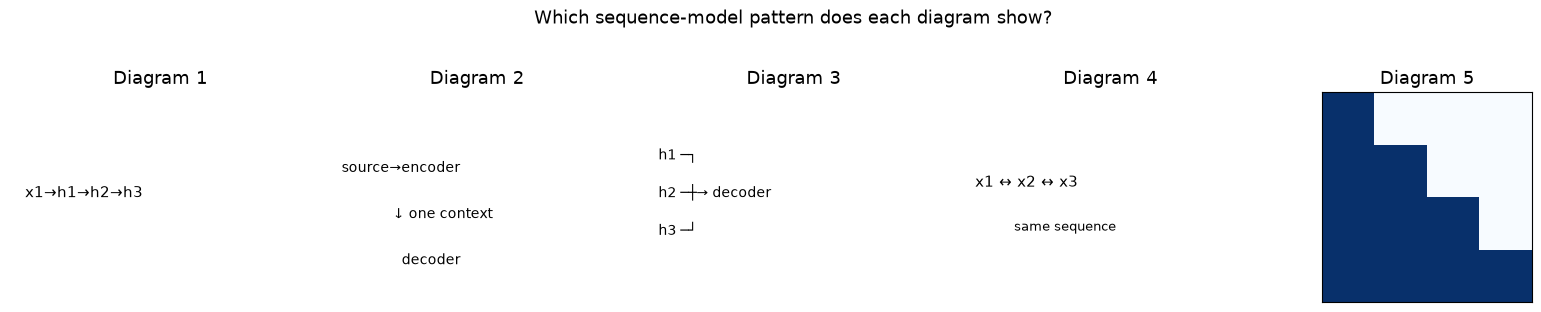

In [17]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
titles = ["Diagram 1", "Diagram 2", "Diagram 3", "Diagram 4", "Diagram 5"]

# 1: recurrent chain
axes[0].text(0.05, 0.5, "x1→h1→h2→h3", fontsize=11)

# 2: fixed context
axes[1].text(0.05, 0.62, "source→encoder", fontsize=10)
axes[1].text(0.22, 0.40, "↓ one context", fontsize=10)
axes[1].text(0.25, 0.18, "decoder", fontsize=10)

# 3: attention-enhanced encoder-decoder
axes[2].text(0.05, 0.68, "h1 ─┐", fontsize=10)
axes[2].text(0.05, 0.50, "h2 ─┼→ decoder", fontsize=10)
axes[2].text(0.05, 0.32, "h3 ─┘", fontsize=10)

# 4: same-sequence interactions
axes[3].text(0.05, 0.55, "x1 ↔ x2 ↔ x3", fontsize=11)
axes[3].text(0.18, 0.34, "same sequence", fontsize=9)

# 5: triangular visibility
triangle = np.tril(np.ones((4, 4)))
axes[4].imshow(triangle, cmap="Blues", vmin=0, vmax=1)
axes[4].set_xticks([])
axes[4].set_yticks([])

for ax, title in zip(axes, titles):
    ax.set_title(title)
    if title != "Diagram 5":
        ax.set(xlim=(0, 1), ylim=(0, 1))
        ax.axis("off")

fig.suptitle("Which sequence-model pattern does each diagram show?", y=1.03)
plt.tight_layout()
plt.show()

## 38. Small numerical exercises

1. Verify that `[0.10, 0.20, 0.30, 0.40]` sums to 1.
2. Given `h1 = [1, 0]`, `h2 = [0, 1]`, and weights `[0.8, 0.2]`, calculate the context vector.
3. Change the weights to `[0.1, 0.9]`. Calculate the new context and explain the change.
4. If a fixed-context encoder grows from 10 to 100 source tokens but keeps the same state size, why may compression become harder?
5. In the Section 20 heatmap, which source position is most relevant to target `Y`?

Work these out on paper or in a new cell before checking below.

## Quiz answers — check after attempting

<details>
<summary><strong>Mini theory quiz answers</strong></summary>

1. Grammar, ordering, and meaning need not align position by position.
2. Information from other sequence positions.
3. A carried representation of useful earlier information.
4. The recurrent representation updated at one position.
5. The state returns into the next repeated computation.
6. It processes the source sequence.
7. It generates the target sequence.
8. A numerical summary or dynamically weighted source representation.
9. It served as the single source summary passed to the decoder.
10. All source information must fit into one fixed-sized summary.
11. It adds representational capacity.
12. The decoder still depends on one compressed representation.
13. A relationship spanning considerably separated positions.
14. Backward learning signals may shrink across repeated operations.
15. To preserve and learn longer-term recurrent information more effectively.
16. It provides a controlled memory path.
17. It improves survival of information but not direct access to every source state.
18. It let the decoder dynamically combine encoder states.
19. Encoder hidden representations associated with source positions.
20. That representation contributes more to the current context.
21. Sum each encoder state multiplied by its weight.
22. Using different attention patterns at different output steps.
23. Learning non-fixed relationships between source and target positions.
24. The influential Bahdanau attention paper appeared.
25. The Transformer made attention central without requiring recurrence.
26. Positions can interact without passing through a recurrent state chain.
27. Token order or location.
28. A decoder relates to representations from a source encoder.
29. Attention among representations in one sequence.
30. Same-sequence, not self-only.
31. Each interacts with different surrounding words.
32. Future tokens must be hidden during next-token prediction.
33. To provide multiple learned projections/subspaces in parallel.

**Section 5 checkpoint:** unlike an ordinary feed-forward pass over independent items, an RNN reuses its previous hidden state at the next sequence position.
</details>

<details>
<summary><strong>Visual identification answers</strong></summary>

1. A — Vanilla RNN  
2. B — Encoder–decoder with fixed context  
3. C — Attention-enhanced encoder–decoder  
4. D — Self-attention  
5. E — Causal attention
</details>

<details>
<summary><strong>Numerical exercise solutions</strong></summary>

1. `0.10 + 0.20 + 0.30 + 0.40 = 1.00`.
2. `0.8[1,0] + 0.2[0,1] = [0.8, 0.2]`.
3. `0.1[1,0] + 0.9[0,1] = [0.1, 0.9]`; the context moves toward `h2`.
4. More information must be represented in the same fixed amount of space.
5. Source `B`, with illustrative weight `0.80`.
</details>

## 39. Final “Can I explain this?” checklist

- [ ] why independent word processing fails
- [ ] why sequence models need context
- [ ] memory, hidden state, and recurrence in an RNN
- [ ] encoder, decoder, and context vector
- [ ] why the final-state bottleneck exists
- [ ] why larger hidden states help but do not remove it
- [ ] vanishing gradients intuitively
- [ ] why LSTM was invented
- [ ] how LSTM and attention solve different problems
- [ ] what Bahdanau attention changed
- [ ] attention weights and weighted context vectors
- [ ] dynamic focus and learned alignment
- [ ] why translation order need not match
- [ ] the significance of 2014 attention and the 2017 Transformer
- [ ] recurrent information flow vs Transformer interactions
- [ ] token information vs positional information vs attention
- [ ] traditional attention vs self-attention
- [ ] why “self” means same-sequence
- [ ] static token embeddings vs contextual representations
- [ ] the basic purpose of causal and multi-head attention

## 40. Final summary

**RNN:** “Carry information forward through a hidden state.”

**LSTM:** “Make recurrent memory easier to preserve and train.”

**Bahdanau attention:** “Do not depend only on one final summary. Dynamically retrieve relevant encoder information.”

**Transformer:** “Make attention the central sequence interaction mechanism instead of relying on recurrence.”

**Self-attention:** “Within one sequence, let each position determine which other positions are relevant.”

---

## Next notebook

# Simplified Self-Attention from Scratch

We will finally begin calculating attention numerically. That is the exact boundary of this conceptual notebook.